# Notebook 05 — Thesis Appendices (B–D) and supplementary outputs



**Printed thesis:** Appendix A (administrative form) appears only in the PDF. This notebook starts with **Appendix B** (model selection and GARCH diagnostics), then **Appendix C** (coefficient estimates), **Appendix D** (data characteristics).



Further sections (**supplementary**) repeat stepwise ARIMA diagnostics, full AIC grids, residual plots, rolling OOS figures, and Ridge/Lasso tables — useful for replication but not necessarily all in the printed appendix.



Uses processed CSVs under `DXY_part/` and `EMCI_part/`. Run **01 → 02 → 03** in each part first; run this notebook with the **repository root** as the working directory.



In [1]:


import warnings

from pathlib import Path



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import pmdarima as pm



from arch import arch_model

from sklearn.linear_model import RidgeCV, LassoCV

from sklearn.model_selection import TimeSeriesSplit

from sklearn.preprocessing import StandardScaler

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.tsa.stattools import adfuller, kpss



warnings.filterwarnings("ignore")



ROOT = Path.cwd().resolve()

if (ROOT / "DXY_part").is_dir():

    pass

elif (ROOT.parent / "DXY_part").is_dir():

    ROOT = ROOT.parent

elif ROOT.name == "notebooks" and (ROOT.parent.parent / "DXY_part").is_dir():

    ROOT = ROOT.parent.parent

elif ROOT.name == "notebooks" and (ROOT.parent / "DXY_part").is_dir():

    ROOT = ROOT.parent



DXY = ROOT / "DXY_part"

EMCI = ROOT / "EMCI_part"

OUT_TABLES = ROOT / "reports" / "tables"

OUT_FIGS = ROOT / "reports" / "figures"

OUT_TABLES.mkdir(parents=True, exist_ok=True)

OUT_FIGS.mkdir(parents=True, exist_ok=True)



plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({

    "figure.figsize": (14, 8),

    "font.size": 13,

    "axes.titlesize": 15,

    "axes.labelsize": 13,

    "legend.fontsize": 11,

})



RANDOM_SEED = 42

REFIT_EVERY = 21



def fit_twostep_arima_garch_nb02(panel: dict):
    """Same two-step ARIMA+GARCH as notebook 02 (auto_arima + GARCH-t on resid*100)."""
    import sys

    root = panel["spec"]["root"]
    path = str(root.resolve())
    if path not in sys.path:
        sys.path.insert(0, path)
    from src.models.twostep_model import TwoStepARIMAGARCHModel

    m = TwoStepARIMAGARCHModel(
        max_p=5,
        max_q=5,
        max_d=1,
        dist="t",
        information_criterion="aic",
    )
    m.fit(panel["y_train"].dropna())
    return m


def ensure_panel_src_path(panel: dict) -> None:
    import sys

    path = str(panel["spec"]["root"].resolve())
    if path not in sys.path:
        sys.path.insert(0, path)


def fit_twostep_arimax_garch_nb02(panel: dict):
    """Two-step ARIMAX+GARCH as NB02 (auto_arima on y with exog + GARCH-t on resid*100)."""
    ensure_panel_src_path(panel)
    from src.models.twostep_model import TwoStepARIMAGARCHModel

    m = TwoStepARIMAGARCHModel(
        max_p=5,
        max_q=5,
        max_d=1,
        dist="t",
        information_criterion="aic",
    )
    y = panel["y_train"].dropna()
    ex = panel["exog_train"].loc[y.index]
    m.fit(y, exog=ex)
    return m


def fit_joint_ar_garch_nb02(panel: dict):
    """Joint AR(p)+GARCH(1,1), AIC over p in {0,…,5} — same class as NB02."""
    ensure_panel_src_path(panel)
    from src.models.arimagarch_model import ARIMAGARCHModel

    m = ARIMAGARCHModel(max_lags=5, information_criterion="aic")
    m.fit(panel["y_train"].dropna())
    return m


def fit_joint_arx_garch_nb02(panel: dict):
    """Joint ARX(p)+GARCH(1,1), AIC over p in {0,…,5} — same class as NB02."""
    ensure_panel_src_path(panel)
    from src.models.arimagarch_model import ARIMAGARCHModel

    y = panel["y_train"].dropna()
    ex = panel["exog_train"].loc[y.index]
    m = ARIMAGARCHModel(max_lags=5, information_criterion="aic")
    m.fit(y, exog=ex)
    return m


print(f"Project root: {ROOT}")

print(f"Tables out:   {OUT_TABLES}")

print(f"Figures out:  {OUT_FIGS}")



Project root: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy
Tables out:   C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables
Figures out:  C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\figures


In [2]:


DXY_EXOG = ["EEM", "HG=F", "^TNX", "GC=F", "CL=F", "EURUSD=X", "GBPUSD=X", "CAD=X", "^GSPC"]

EEM_EXOG = ["DX-Y.NYB", "^VIX", "^TNX", "CL=F", "HG=F", "GC=F", "^GSPC", "CAD=X", "JPY=X"]



# Two-step orders: TwoStepARIMAGARCHModel (NB02). Joint AR/ARX p: ARIMAGARCHModel + AIC (NB02).



PANEL_SPECS = {

    "DXY": {

        "root": DXY,

        "feature_csv": DXY / "data" / "processed" / "dxy_dataset_features.csv",

        "target_csv": DXY / "data" / "processed" / "dxy_dataset_target.csv",

        "exog_cols": DXY_EXOG,

        "arima_order": (0, 0, 0),

        "arimax_order": (0, 0, 1),

    },

    "EEM": {

        "root": EMCI,

        "feature_csv": EMCI / "data" / "processed" / "eem_dataset_features.csv",

        "target_csv": EMCI / "data" / "processed" / "eem_dataset_target.csv",

        "exog_cols": EEM_EXOG,

        "arima_order": (2, 0, 1),

        "arimax_order": (2, 0, 1),

    },

}





def load_processed_panel(asset: str) -> dict:

    spec = PANEL_SPECS[asset]

    X_full = pd.read_csv(spec["feature_csv"], index_col=0, parse_dates=True)

    y_df = pd.read_csv(spec["target_csv"], index_col=0, parse_dates=True)

    y = y_df.iloc[:, 0].astype(float)



    lag_cols = [c for c in X_full.columns if "target" in c.lower() and "lag" in c.lower()]

    exog_cols = [c for c in spec["exog_cols"] if c in X_full.columns]



    X = X_full[lag_cols + exog_cols].copy()

    X["vol_21"] = y.rolling(21).std()

    X["vol_63"] = y.rolling(63).std()

    X = X.dropna()

    y = y.loc[X.index]



    shift_cols = exog_cols + ["vol_21", "vol_63"]

    X[shift_cols] = X[shift_cols].shift(1)

    X = X.dropna()

    y = y.loc[X.index]



    train_size = int(len(y) * 0.8)

    return {

        "asset": asset,

        "spec": spec,

        "X_full": X_full,

        "target_full": y_df.iloc[:, 0].astype(float),

        "X": X,

        "y": y,

        "exog": X[exog_cols],

        "exog_cols": exog_cols,

        "lag_cols": lag_cols,

        "train_size": train_size,

        "y_train": y.iloc[:train_size],

        "X_train": X.iloc[:train_size],

        "exog_train": X[exog_cols].iloc[:train_size],

        "y_test": y.iloc[train_size:],

    }





def fit_sarimax(y, order, exog=None):

    exog_data = None if exog is None else exog.loc[y.index]

    model = SARIMAX(

        y,

        exog=exog_data,

        order=order,

        trend="c",

        enforce_stationarity=False,

        enforce_invertibility=False,

    )

    return model.fit(disp=False, method="lbfgs")





def fit_twostep_garch(y_train, order, exog_train=None):

    sarimax_res = fit_sarimax(y_train, order=order, exog=exog_train)

    resid = pd.Series(sarimax_res.resid, index=y_train.index[-len(sarimax_res.resid):]).dropna()

    garch_res = arch_model(

        resid * 100,

        mean="Zero",

        vol="GARCH",

        p=1,

        q=1,

        dist="t",

    ).fit(disp="off", show_warning=False)

    return sarimax_res, garch_res





def result_table_from_sarimax(res, asset, model_name):

    names = list(res.params.index)

    return pd.DataFrame({

        "asset": asset,

        "model": model_name,

        "parameter": names,

        "estimate": res.params.values,

        "std_error": res.bse.values,

        "t_stat": res.tvalues.values,

        "p_value": res.pvalues.values,

    })





def save_table(df, filename):

    path = OUT_TABLES / filename

    df.to_csv(path, index=False)

    print(f"Saved: {path}")

    return path





def fit_joint_ar_garch_on_train(panel, p: int):

    y_s = panel["y_train"].dropna() * 100

    if p == 0:

        model = arch_model(y_s, mean="Constant", vol="GARCH", p=1, q=1, dist="t")

    else:

        model = arch_model(y_s, mean="AR", lags=p, vol="GARCH", p=1, q=1, dist="t")

    return model.fit(disp="off", show_warning=False)





def fit_joint_arx_garch(panel, ar_lags=5):

    y_s = panel["y_train"].dropna() * 100

    exog_fit = panel["exog_train"].loc[y_s.index]

    model = arch_model(

        y_s,

        mean="ARX",

        lags=ar_lags,

        x=exog_fit,

        vol="GARCH",

        p=1,

        q=1,

        dist="t",

    )

    return model.fit(disp="off", show_warning=False)





def garch_vol_rows_from_arch_result(fitted, asset, mean_label):

    rows = []

    for param in ["omega", "alpha[1]", "beta[1]", "nu"]:

        rows.append({

            "asset": asset,

            "mean_model": mean_label,

            "parameter": param,

            "estimate": float(fitted.params.get(param, np.nan)),

            "std_error": float(fitted.std_err.get(param, np.nan)),

            "t_stat": float(fitted.tvalues.get(param, np.nan)),

            "p_value": float(fitted.pvalues.get(param, np.nan)),

        })

    return pd.DataFrame(rows)





def joint_arx_garch_parameter_table(res, asset, ar_lags=5):

    params = pd.Series(res.params)

    rows = []

    for parameter in params.index:

        if parameter in {"omega", "alpha[1]", "beta[1]"}:

            component = "volatility"

        elif parameter == "nu":

            component = "distribution"

        else:

            component = "mean"



        if component == "mean" and not parameter.startswith("target["):

            scale_factor = 100.0

            reported_units = "raw_return"

        elif parameter == "omega":

            scale_factor = 10_000.0

            reported_units = "raw_return_variance"

        else:

            scale_factor = 1.0

            reported_units = "dimensionless"



        rows.append({

            "asset": asset,

            "model": f"Joint ARX({ar_lags})+GARCH(1,1)",

            "component": component,

            "parameter": parameter,

            "estimate": float(res.params[parameter]) / scale_factor,

            "std_error": float(res.std_err[parameter]) / scale_factor,

            "t_stat": float(res.tvalues[parameter]),

            "p_value": float(res.pvalues[parameter]),

            "reported_units": reported_units,

        })

    return pd.DataFrame(rows)





panels = {asset: load_processed_panel(asset) for asset in PANEL_SPECS}

for asset, panel in panels.items():

    print(f"{asset}: modelling rows={len(panel['y'])}, train={panel['train_size']}, test={len(panel['y']) - panel['train_size']}, exog={panel['exog_cols']}")



DXY: modelling rows=5263, train=4210, test=1053, exog=['EEM', 'HG=F', '^TNX', 'GC=F', 'CL=F', 'EURUSD=X', 'GBPUSD=X', 'CAD=X', '^GSPC']
EEM: modelling rows=5258, train=4206, test=1052, exog=['DX-Y.NYB', '^VIX', '^TNX', 'CL=F', 'HG=F', 'GC=F', '^GSPC', 'CAD=X', 'JPY=X']


## Appendix B — Model Selection and Diagnostics



### B.1 GARCH(1,1) parameter estimates — Table B.1 (two-step ARIMA+GARCH)



Refits the two-step mean equation on the NB02 training split and reports Student-t GARCH(1,1) parameters on ARIMA residuals scaled by 100 (`arch`).


In [3]:


twostep_fits = {}

garch_rows = []



for asset, panel in panels.items():

    m = fit_twostep_arima_garch_nb02(panel)

    order = m.order

    garch_res = m._garch_result

    sarimax_res = m._arima_result

    twostep_fits[(asset, "ARIMA+GARCH")] = {
        "sarimax": sarimax_res,
        "garch": garch_res,
        "twostep": m,
    }

    _nu = float(garch_res.params.get("nu", float("nan")))

    print(f"  B.1 {asset}: ARIMA{order}, nu={_nu:.6f}")


    for param in ["omega", "alpha[1]", "beta[1]", "nu"]:

        garch_rows.append({

            "asset": asset,

            "table": "B.1",

            "mean_model_order": str(order),

            "parameter": param,

            "estimate": float(garch_res.params.get(param, np.nan)),

            "std_error": float(garch_res.std_err.get(param, np.nan)),

            "t_stat": float(garch_res.tvalues.get(param, np.nan)),

            "p_value": float(garch_res.pvalues.get(param, np.nan)),

        })



garch_b1 = pd.DataFrame(garch_rows)

garch_b1["estimate_se"] = garch_b1.apply(

    lambda r: f"{r['estimate']:.6f} ({r['std_error']:.6f})", axis=1

)

garch_b1_wide = garch_b1.pivot(index="parameter", columns="asset", values="estimate_se").reset_index()



save_table(garch_b1, "appendix_b1_twostep_garch_parameter_estimates_long.csv")

save_table(garch_b1_wide, "appendix_b1_twostep_garch_parameter_estimates_wide.csv")

# Backward-compatible aliases

save_table(garch_b1.drop(columns=["table"], errors="ignore"), "appendix_c_garch_parameter_estimates_long.csv")

save_table(garch_b1_wide, "appendix_c_garch_parameter_estimates_wide.csv")

garch_b1_wide



  B.1 DXY: ARIMA(0, 0, 0), nu=10.153000
  B.1 EEM: ARIMA(2, 0, 1), nu=8.742230
Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_b1_twostep_garch_parameter_estimates_long.csv
Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_b1_twostep_garch_parameter_estimates_wide.csv
Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_c_garch_parameter_estimates_long.csv
Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_c_garch_parameter_estimates_wide.csv


asset,parameter,DXY,EEM
0,alpha[1],0.036739 (0.004433),0.096202 (0.012169)
1,beta[1],0.960298 (0.004620),0.890412 (0.013366)
2,nu,10.153000 (1.463853),8.742230 (1.134579)
3,omega,0.000746 (0.000319),0.038261 (0.009396)


### Table B.2 — Joint AR(p)+GARCH(1,1) parameter estimates



Joint maximum likelihood with Student-t innovations; returns scaled by 100 in estimation. Lag $p$ is selected by **AIC** over $\{0,\ldots,5\}$ via `ARIMAGARCHModel`, same as NB02.


In [4]:


rows_b2 = []

for asset, panel in panels.items():

    jm = fit_joint_ar_garch_nb02(panel)

    res = jm.fitted_model

    p = jm.best_lags

    label = f"AR({p})+GARCH(1,1)"

    print(f"  B.2 {asset}: {label} (AIC)")

    sub = garch_vol_rows_from_arch_result(res, asset, label)

    sub["table"] = "B.2"

    rows_b2.append(sub)



garch_b2_long = pd.concat(rows_b2, ignore_index=True)

garch_b2_long["estimate_se"] = garch_b2_long.apply(

    lambda r: f"{r['estimate']:.6f} ({r['std_error']:.6f})", axis=1

)

garch_b2_wide = garch_b2_long.pivot_table(

    index="parameter", columns=["asset", "mean_model"], values="estimate_se", aggfunc="first"

)

save_table(garch_b2_long, "appendix_b2_joint_ar_garch_parameter_estimates_long.csv")

save_table(garch_b2_wide.reset_index(), "appendix_b2_joint_ar_garch_parameter_estimates_wide.csv")

garch_b2_long



  B.2 DXY: AR(0)+GARCH(1,1) (AIC)
  B.2 EEM: AR(5)+GARCH(1,1) (AIC)
Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_b2_joint_ar_garch_parameter_estimates_long.csv
Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_b2_joint_ar_garch_parameter_estimates_wide.csv


,asset,mean_model,parameter,estimate,std_error,t_stat,p_value,table,estimate_se
0,DXY,"AR(0)+GARCH(1,1)",omega,0.000747,0.000318,2.345630,1.899495e-02,B.2,0.000747 (0.000318)
1,DXY,"AR(0)+GARCH(1,1)",alpha[1],0.036706,0.004434,8.278871,1.243487e-16,B.2,0.036706 (0.004434)
2,DXY,"AR(0)+GARCH(1,1)",beta[1],0.960323,0.004619,207.892155,0.000000e+00,B.2,0.960323 (0.004619)
3,DXY,"AR(0)+GARCH(1,1)",nu,10.145221,1.462545,6.936689,4.013972e-12,B.2,10.145221 (1.462545)
4,EEM,"AR(5)+GARCH(1,1)",omega,0.039624,0.009572,4.139731,3.477130e-05,B.2,0.039624 (0.009572)
5,EEM,"AR(5)+GARCH(1,1)",alpha[1],0.100247,0.012384,8.095099,5.721763e-16,B.2,0.100247 (0.012384)
6,EEM,"AR(5)+GARCH(1,1)",beta[1],0.885968,0.013631,64.995506,0.000000e+00,B.2,0.885968 (0.013631)
7,EEM,"AR(5)+GARCH(1,1)",nu,8.633667,1.135681,7.602192,2.911560e-14,B.2,8.633667 (1.135681)


### Table B.3 — Joint ARX($p$)+GARCH(1,1) volatility parameters



Variance and tail parameters from `ARIMAGARCHModel` with $p$ chosen by **AIC** on $\{0,\ldots,5\}$ (NB02). Mean-equation coefficients are in Appendix C.


In [5]:


joint_arx_fits = {}

joint_arx_ar_lags = {}

rows_b3 = []



for asset, panel in panels.items():

    jm = fit_joint_arx_garch_nb02(panel)

    res = jm.fitted_model

    p = jm.best_lags

    joint_arx_fits[asset] = res

    joint_arx_ar_lags[asset] = p

    label = f"ARX({p})+GARCH(1,1)"

    print(f"  B.3 {asset}: {label} (AIC)")

    sub = garch_vol_rows_from_arch_result(res, asset, label)

    sub["table"] = "B.3"

    rows_b3.append(sub)



garch_b3_long = pd.concat(rows_b3, ignore_index=True)

garch_b3_long["estimate_se"] = garch_b3_long.apply(

    lambda r: f"{r['estimate']:.6f} ({r['std_error']:.6f})", axis=1

)

save_table(garch_b3_long, "appendix_b3_joint_arx_garch_volatility_estimates_long.csv")

garch_b3_long



  B.3 DXY: ARX(5)+GARCH(1,1) (AIC)
  B.3 EEM: ARX(5)+GARCH(1,1) (AIC)
Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_b3_joint_arx_garch_volatility_estimates_long.csv


,asset,mean_model,parameter,estimate,std_error,t_stat,p_value,table,estimate_se
0,DXY,"ARX(5)+GARCH(1,1)",omega,0.000682,0.000292,2.337677,1.940401e-02,B.3,0.000682 (0.000292)
1,DXY,"ARX(5)+GARCH(1,1)",alpha[1],0.035486,0.004187,8.475068,2.349421e-17,B.3,0.035486 (0.004187)
2,DXY,"ARX(5)+GARCH(1,1)",beta[1],0.961678,0.004358,220.667356,0.000000e+00,B.3,0.961678 (0.004358)
3,DXY,"ARX(5)+GARCH(1,1)",nu,11.018990,1.767933,6.232696,4.584756e-10,B.3,11.018990 (1.767933)
4,EEM,"ARX(5)+GARCH(1,1)",omega,0.037208,0.009276,4.011088,6.043953e-05,B.3,0.037208 (0.009276)
5,EEM,"ARX(5)+GARCH(1,1)",alpha[1],0.097795,0.012365,7.909077,2.593042e-15,B.3,0.097795 (0.012365)
6,EEM,"ARX(5)+GARCH(1,1)",beta[1],0.889330,0.013545,65.657013,0.000000e+00,B.3,0.889330 (0.013545)
7,EEM,"ARX(5)+GARCH(1,1)",nu,8.384953,1.073829,7.808464,5.788933e-15,B.3,8.384953 (1.073829)


### B.2 ARX–GARCH model selection — Table B.4



Joint ARX($p$)+GARCH(1,1) AIC for $p=0,\ldots,5$; $\Delta$AIC vs the best model within each asset (thesis-style top block). Full grid (through $p=8$) is saved under *Supplementary* outputs.


In [6]:


def joint_arx_garch_grid(panel, max_lags=5):

    ensure_panel_src_path(panel)

    from src.models.arimagarch_model import ARIMAGARCHModel

    rows = []

    for p in range(max_lags + 1):

        try:

            m = ARIMAGARCHModel(max_lags=max_lags, information_criterion="aic")

            m.best_lags = p

            m.fit(panel["y_train"].dropna(), exog=panel["exog_train"], select_lags=False)

            res = m.fitted_model

            rows.append({

                "asset": panel["asset"],

                "model": f"ARX({p})+GARCH(1,1)",

                "ar_lag": p,

                "aic": float(res.aic),

                "delta_aic": np.nan,

            })

        except Exception as exc:

            rows.append({

                "asset": panel["asset"],

                "model": f"ARX({p})+GARCH(1,1)",

                "ar_lag": p,

                "aic": np.nan,

                "delta_aic": np.nan,

                "error": repr(exc),

            })

    return pd.DataFrame(rows)





def compact_b4_table(grid_all):

    frames = []

    for asset in grid_all["asset"].unique():

        g = grid_all[(grid_all["asset"] == asset) & grid_all["aic"].notna()].copy()

        if g.empty:

            continue

        best = g["aic"].min()

        g["delta_aic"] = g["aic"] - best

        g = g.nsmallest(3, "aic")

        frames.append(g)

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()





grid_b4 = pd.concat([joint_arx_garch_grid(panel, max_lags=5) for panel in panels.values()], ignore_index=True)

table_b4 = compact_b4_table(grid_b4)

save_table(table_b4, "appendix_b4_joint_arx_garch_aic_ranking_top3.csv")

save_table(grid_b4, "appendix_b4_joint_arx_garch_aic_grid_p0_p5.csv")

table_b4



Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_b4_joint_arx_garch_aic_ranking_top3.csv
Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_b4_joint_arx_garch_aic_grid_p0_p5.csv


,asset,model,ar_lag,aic,delta_aic
0,DXY,"ARX(5)+GARCH(1,1)",5,4918.289086,0.000000
1,DXY,"ARX(3)+GARCH(1,1)",3,4918.710051,0.420965
2,DXY,"ARX(1)+GARCH(1,1)",1,4919.248110,0.959024
3,EEM,"ARX(5)+GARCH(1,1)",5,14716.021151,0.000000
4,EEM,"ARX(4)+GARCH(1,1)",4,14720.493195,4.472044
5,EEM,"ARX(3)+GARCH(1,1)",3,14723.574998,7.553847


## Appendix C — Coefficient Estimates



### C.1 Table C.1 — Two-step ARIMAX mean equation (coefficients)



SARIMAX estimates for the ARIMAX orders used in NB02 (two-step procedure; GARCH stage separate).


In [7]:


arimax_fits = {}

arimax_coef_tables = []



for asset, panel in panels.items():

    tm = fit_twostep_arimax_garch_nb02(panel)

    order = tm.order

    res = tm._arima_result

    arimax_fits[asset] = res

    print(f"  C.1 {asset}: ARIMAX{order} (TwoStep / NB02)")

    arimax_coef_tables.append(result_table_from_sarimax(res, asset=asset, model_name=f"ARIMAX{order}"))



arimax_coefficients = pd.concat(arimax_coef_tables, ignore_index=True)

save_table(arimax_coefficients, "appendix_c1_arimax_coefficient_estimates.csv")

save_table(arimax_coefficients, "appendix_g_arimax_coefficient_estimates.csv")

arimax_coefficients



  C.1 DXY: ARIMAX(0, 0, 1) (TwoStep / NB02)
  C.1 EEM: ARIMAX(2, 0, 1) (TwoStep / NB02)
Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_c1_arimax_coefficient_estimates.csv
Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_g_arimax_coefficient_estimates.csv


,asset,model,parameter,estimate,std_error,t_stat,p_value
0,DXY,"ARIMAX(0, 0, 1)",intercept,0.000043,7.115440e-05,0.601928,5.472220e-01
1,DXY,"ARIMAX(0, 0, 1)",x1,-0.014045,5.721655e-03,-2.454764,1.409773e-02
2,DXY,"ARIMAX(0, 0, 1)",x2,0.006860,3.913801e-03,1.752670,7.965865e-02
3,DXY,"ARIMAX(0, 0, 1)",x3,0.010191,2.122968e-03,4.800263,1.584574e-06
4,DXY,"ARIMAX(0, 0, 1)",x4,0.000320,5.726899e-03,0.055797,9.555032e-01
5,DXY,"ARIMAX(0, 0, 1)",x5,-0.000945,2.578020e-03,-0.366481,7.140065e-01
6,DXY,"ARIMAX(0, 0, 1)",x6,-0.004707,9.418212e-03,-0.499829,6.171956e-01
7,DXY,"ARIMAX(0, 0, 1)",x7,-0.028386,1.240317e-02,-2.288571,2.210428e-02
8,DXY,"ARIMAX(0, 0, 1)",x8,0.002243,1.292024e-02,0.173623,8.621616e-01
9,DXY,"ARIMAX(0, 0, 1)",x9,-0.036669,9.043539e-03,-4.054756,5.018657e-05


### C.2 Table C.2 — Joint ARX($p$)+GARCH(1,1) full parameter table



Uses the fits from **Table B.3** (`joint_arx_fits`, AIC-selected $p$). Mean-equation coefficients are scaled back to raw-return units where noted.


In [8]:


joint_arx_coef_tables = [

    joint_arx_garch_parameter_table(

        joint_arx_fits[asset], asset=asset, ar_lags=joint_arx_ar_lags[asset]

    )

    for asset in PANEL_SPECS

]

joint_arx_coefficients = pd.concat(joint_arx_coef_tables, ignore_index=True)

save_table(joint_arx_coefficients, "appendix_c2_joint_arx_garch_coefficient_estimates.csv")

save_table(joint_arx_coefficients, "appendix_g2_joint_arx_garch_coefficient_estimates.csv")

joint_arx_coefficients



Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_c2_joint_arx_garch_coefficient_estimates.csv
Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_g2_joint_arx_garch_coefficient_estimates.csv


,asset,model,component,parameter,estimate,std_error,t_stat,p_value,reported_units
0,DXY,"Joint ARX(5)+GARCH(1,1)",mean,Const,2.982117e-05,6.084350e-05,0.490129,6.240425e-01,raw_return
1,DXY,"Joint ARX(5)+GARCH(1,1)",mean,target[1],-4.156732e-02,1.855445e-02,-2.240288,2.507222e-02,dimensionless
2,DXY,"Joint ARX(5)+GARCH(1,1)",mean,target[2],-9.021161e-03,1.915320e-02,-0.471000,6.376405e-01,dimensionless
3,DXY,"Joint ARX(5)+GARCH(1,1)",mean,target[3],-1.950507e-02,1.512365e-02,-1.289707,1.971525e-01,dimensionless
4,DXY,"Joint ARX(5)+GARCH(1,1)",mean,target[4],-1.255040e-02,1.550084e-02,-0.809660,4.181358e-01,dimensionless
5,DXY,"Joint ARX(5)+GARCH(1,1)",mean,target[5],7.739167e-03,1.535082e-02,0.504153,6.141536e-01,dimensionless
6,DXY,"Joint ARX(5)+GARCH(1,1)",mean,EEM,-1.020725e-02,7.979432e-03,-1.279195,2.008284e-01,raw_return
7,DXY,"Joint ARX(5)+GARCH(1,1)",mean,HG=F,3.846540e-03,5.223644e-03,0.736371,4.615050e-01,raw_return
8,DXY,"Joint ARX(5)+GARCH(1,1)",mean,^TNX,1.060225e-02,3.761238e-03,2.818818,4.820079e-03,raw_return
9,DXY,"Joint ARX(5)+GARCH(1,1)",mean,GC=F,-8.505373e-03,8.158805e-03,-1.042478,2.971902e-01,raw_return


## Appendix D — Data Characteristics



### D.1 Table D.1 — ADF and KPSS (exogenous log-returns)



Panel-long file keeps both DXY and EEM panels; **thesis-style** summary deduplicates by canonical predictor name (one row per series).


In [9]:


FEATURE_TICKER_LABELS = {

    "^VIX": "VIX",

    "^TNX": "TNX",

    "^GSPC": "S&P 500",

    "CL=F": "WTI Oil",

    "HG=F": "Copper",

    "GC=F": "Gold",

    "GBPUSD=X": "GBP/USD",

    "EURUSD=X": "EUR/USD",

    "JPY=X": "USD/JPY",

    "CAD=X": "USD/CAD",

    "DX-Y.NYB": "DXY",

    "EEM": "EEM",

}





def canonical_name(ticker: str) -> str:

    return FEATURE_TICKER_LABELS.get(ticker, ticker)





stationarity_rows = []



for asset, panel in panels.items():

    for col in panel["exog_cols"]:

        s = panel["exog"][col].dropna()

        adf_stat, adf_p, adf_lag, adf_nobs, adf_cv, adf_ic = adfuller(s, regression="c", autolag="AIC")

        kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(s, regression="c", nlags="auto")

        stationarity_rows.append({

            "asset_panel": asset,

            "variable": col,

            "canonical": canonical_name(col),

            "nobs": int(len(s)),

            "adf_stat": float(adf_stat),

            "adf_p_value": float(adf_p),

            "adf_lags": int(adf_lag),

            "adf_stationary_5pct": bool(adf_p < 0.05),

            "kpss_stat": float(kpss_stat),

            "kpss_p_value": float(kpss_p),

            "kpss_lags": int(kpss_lags),

            "kpss_stationary_5pct": bool(kpss_p >= 0.05),

        })



stationarity_table = pd.DataFrame(stationarity_rows)

stationarity_table["joint_conclusion"] = np.where(

    stationarity_table["adf_stationary_5pct"] & stationarity_table["kpss_stationary_5pct"],

    "Stationary by ADF and KPSS",

    "Mixed / review",

)



save_table(stationarity_table, "appendix_d1_adf_kpss_exogenous_returns_by_panel.csv")

save_table(stationarity_table, "appendix_d_adf_kpss_exogenous_returns.csv")



# Thesis-style: one row per canonical series (first panel occurrence wins; series are identical)

st_d1_thesis = (

    stationarity_table.sort_values(["canonical", "asset_panel"])

    .groupby("canonical", as_index=False)

    .first()

)

save_table(st_d1_thesis, "appendix_d1_adf_kpss_exogenous_thesis_summary.csv")

stationarity_table.head(10)



Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_d1_adf_kpss_exogenous_returns_by_panel.csv
Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_d_adf_kpss_exogenous_returns.csv
Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_d1_adf_kpss_exogenous_thesis_summary.csv


,asset_panel,variable,canonical,nobs,adf_stat,adf_p_value,adf_lags,adf_stationary_5pct,kpss_stat,kpss_p_value,kpss_lags,kpss_stationary_5pct,joint_conclusion
0,DXY,EEM,EEM,5263,-15.750949,1.223534e-28,19,True,0.067268,0.1,27,True,Stationary by ADF and KPSS
1,DXY,HG=F,Copper,5263,-19.871761,0.000000e+00,11,True,0.090303,0.1,7,True,Stationary by ADF and KPSS
2,DXY,^TNX,TNX,5263,-12.020189,3.036227e-22,33,True,0.154902,0.1,5,True,Stationary by ADF and KPSS
3,DXY,GC=F,Gold,5263,-24.688738,0.000000e+00,8,True,0.208628,0.1,11,True,Stationary by ADF and KPSS
4,DXY,CL=F,WTI Oil,5263,-12.735764,9.168355e-24,24,True,0.063170,0.1,11,True,Stationary by ADF and KPSS
5,DXY,EURUSD=X,EUR/USD,5263,-13.478680,3.273672e-25,29,True,0.038209,0.1,23,True,Stationary by ADF and KPSS
6,DXY,GBPUSD=X,GBP/USD,5263,-15.789282,1.107155e-28,23,True,0.049026,0.1,13,True,Stationary by ADF and KPSS
7,DXY,CAD=X,USD/CAD,5263,-14.697244,2.984994e-27,26,True,0.158825,0.1,9,True,Stationary by ADF and KPSS
8,DXY,^GSPC,S&P 500,5263,-18.377775,2.212187e-30,15,True,0.138475,0.1,24,True,Stationary by ADF and KPSS
9,EEM,DX-Y.NYB,DXY,5258,-21.769167,0.000000e+00,10,True,0.049310,0.1,9,True,Stationary by ADF and KPSS


### D.2 Table D.2 — Descriptive statistics for exogenous predictors (% log-returns)



Aligned modelling sample; panel-long and deduplicated **thesis summary** with skewness and Min/Max.


In [10]:


desc_rows = []

for asset, panel in panels.items():

    for col in panel["exog_cols"]:

        s = panel["exog"][col].dropna()

        desc_rows.append({

            "asset_panel": asset,

            "variable": col,

            "canonical": canonical_name(col),

            "nobs": int(len(s)),

            "mean": float(s.mean()),

            "std": float(s.std(ddof=1)),

            "skewness": float(s.skew()),

            "kurtosis": float(s.kurtosis()),

            "min": float(s.min()),

            "max": float(s.max()),

        })



exog_descriptives = pd.DataFrame(desc_rows)

save_table(exog_descriptives, "appendix_d2_exogenous_descriptive_statistics_by_panel.csv")

save_table(exog_descriptives, "appendix_f_exogenous_descriptive_statistics.csv")





# Table D.2 thesis layout: same predictor order / naming as printed Table D.1 (excludes EEM, DX-Y.NYB;
# shared series use DXY-aligned sample; VIX and JPY from EEM panel).
D2_THESIS_ROWS = [
    ("HG=F", "DXY", "Copper (HG=F)"),
    ("^TNX", "DXY", "10Y Treasury (^TNX)"),
    ("GC=F", "DXY", "Gold (GC=F)"),
    ("CL=F", "DXY", "WTI crude (CL=F)"),
    ("EURUSD=X", "DXY", "EUR/USD (EURUSD=X)"),
    ("GBPUSD=X", "DXY", "GBP/USD (GBPUSD=X)"),
    ("CAD=X", "DXY", "USD/CAD (CAD=X)"),
    ("^GSPC", "DXY", "S&P 500 (^GSPC)"),
    ("^VIX", "EEM", "CBOE Volatility (^VIX)"),
    ("JPY=X", "EEM", "USD/JPY (JPY=X)"),
]


def _d2_thesis_from_descriptives(df):
    rows = []
    for var, panel, label in D2_THESIS_ROWS:
        hit = df[(df["variable"] == var) & (df["asset_panel"] == panel)]
        if hit.empty:
            raise ValueError("D.2 thesis row missing: {!r} @ {!r}".format(var, panel))
        row = hit.iloc[0].to_dict()
        row["thesis_label"] = label
        rows.append(row)
    return pd.DataFrame(rows)


exog_d2_thesis = _d2_thesis_from_descriptives(exog_descriptives)
exog_d2_thesis["min_max"] = exog_d2_thesis.apply(
    lambda r: "{:.2f} / {:.2f}".format(r["min"], r["max"]), axis=1
)
save_table(exog_d2_thesis, "appendix_d2_exogenous_descriptive_thesis_summary.csv")
exog_d2_thesis



Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_d2_exogenous_descriptive_statistics_by_panel.csv
Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_f_exogenous_descriptive_statistics.csv
Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_d2_exogenous_descriptive_thesis_summary.csv


,asset_panel,variable,canonical,nobs,mean,std,skewness,kurtosis,min,max,thesis_label,min_max
0,DXY,HG=F,Copper,5263,0.000259,0.017796,-0.606935,11.113635,-0.251712,0.124437,Copper (HG=F),-0.25 / 0.12
1,DXY,^TNX,TNX,5263,0.000039,0.025733,0.204619,31.720852,-0.347009,0.404797,10Y Treasury (^TNX),-0.35 / 0.40
2,DXY,GC=F,Gold,5263,0.000446,0.011566,-0.544349,7.114662,-0.120657,0.086432,Gold (GC=F),-0.12 / 0.09
3,DXY,CL=F,WTI Oil,5263,0.000243,0.026230,0.075068,18.140334,-0.282206,0.319634,WTI crude (CL=F),-0.28 / 0.32
4,DXY,EURUSD=X,EUR/USD,5263,0.000005,0.007031,0.587396,103.846898,-0.143324,0.159632,EUR/USD (EURUSD=X),-0.14 / 0.16
5,DXY,GBPUSD=X,GBP/USD,5263,-0.000069,0.005875,-0.689126,9.563723,-0.079085,0.034848,GBP/USD (GBPUSD=X),-0.08 / 0.03
6,DXY,CAD=X,USD/CAD,5263,0.000027,0.005363,0.201840,3.555833,-0.036946,0.035984,USD/CAD (CAD=X),-0.04 / 0.04
7,DXY,^GSPC,S&P 500,5263,0.000335,0.012098,-0.477093,13.215521,-0.127652,0.109572,S&P 500 (^GSPC),-0.13 / 0.11
8,EEM,^VIX,VIX,5258,0.000101,0.075945,1.037514,6.524774,-0.442449,0.768245,CBOE Volatility (^VIX),-0.44 / 0.77
9,EEM,JPY=X,USD/JPY,5258,0.000077,0.007370,-0.587680,109.703681,-0.168471,0.162885,USD/JPY (JPY=X),-0.17 / 0.16


---



## Supplementary material (replication)



The following cells are **not** labelled B–D in the printed thesis. They document order selection, extended AIC grids, diagnostics, and ML-related tables.


### Stepwise `auto_arima` (two-step mean orders)



Reproduces `pmdarima.auto_arima(..., stepwise=True)` for ARIMA vs ARIMAX means used in NB02.


In [11]:


def stepwise_auto_arima_selection(panel, use_exog=False):

    y_train = panel["y_train"].dropna()

    exog_train = panel["exog_train"].loc[y_train.index].values if use_exog else None

    m_ref = fit_twostep_arimax_garch_nb02(panel) if use_exog else fit_twostep_arima_garch_nb02(panel)

    expected_order = m_ref.order



    auto = pm.auto_arima(

        y_train,

        X=exog_train,

        max_p=5,

        max_q=5,

        max_d=1,

        information_criterion="aic",

        seasonal=False,

        stepwise=True,

        suppress_warnings=True,

        error_action="ignore",

    )



    return {

        "asset": panel["asset"],

        "specification": "ARIMAX+GARCH mean" if use_exog else "ARIMA+GARCH mean",

        "uses_exog": use_exog,

        "selected_order": str(auto.order),

        "expected_nb02_order": str(expected_order),

        "matches_nb02": auto.order == expected_order,

        "aic": float(auto.aic()),

        "bic": float(auto.bic()),

        "llf": float(auto.arima_res_.llf),

        "estimator": "pmdarima.auto_arima(stepwise=True)",

        "note": "expected_nb02_order = TwoStepARIMAGARCHModel.order (NB02).",

    }





stepwise_rows = []

for panel in panels.values():

    stepwise_rows.append(stepwise_auto_arima_selection(panel, use_exog=False))

    stepwise_rows.append(stepwise_auto_arima_selection(panel, use_exog=True))



stepwise_selection = pd.DataFrame(stepwise_rows)

save_table(stepwise_selection, "appendix_e_stepwise_arima_arimax_selection.csv")

stepwise_selection



Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_e_stepwise_arima_arimax_selection.csv


,asset,specification,uses_exog,selected_order,expected_nb02_order,matches_nb02,aic,bic,llf,estimator,note
0,DXY,ARIMA+GARCH mean,False,"(0, 0, 0)","(0, 0, 0)",True,-33068.643956,-33062.298738,16535.321978,pmdarima.auto_arima(stepwise=True),expected_nb02_order = TwoStepARIMAGARCHModel.o...
1,DXY,ARIMAX+GARCH mean,True,"(0, 0, 1)","(0, 0, 1)",True,-33141.466611,-33071.669214,16581.733305,pmdarima.auto_arima(stepwise=True),expected_nb02_order = TwoStepARIMAGARCHModel.o...
2,EEM,ARIMA+GARCH mean,False,"(2, 0, 1)","(2, 0, 1)",True,-21691.161466,-21665.784396,10849.580733,pmdarima.auto_arima(stepwise=True),expected_nb02_order = TwoStepARIMAGARCHModel.o...
3,EEM,ARIMAX+GARCH mean,True,"(2, 0, 1)","(2, 0, 1)",True,-21771.338395,-21688.862920,10898.669198,pmdarima.auto_arima(stepwise=True),expected_nb02_order = TwoStepARIMAGARCHModel.o...


### Extended AIC tables (two-step ARIMAX components + joint ARX grid up to $p=8$)


In [12]:


def joint_arx_garch_grid_long(panel, max_lags=8):

    ensure_panel_src_path(panel)

    from src.models.arimagarch_model import ARIMAGARCHModel

    rows = []

    for p in range(max_lags + 1):

        try:

            m = ARIMAGARCHModel(max_lags=max_lags, information_criterion="aic")

            m.best_lags = p

            m.fit(panel["y_train"].dropna(), exog=panel["exog_train"], select_lags=False)

            res = m.fitted_model

            rows.append({

                "asset": panel["asset"],

                "model_family": "Joint ARX-GARCH",

                "component": "joint_mean_variance",

                "order": f"ARX({p})+GARCH(1,1)",

                "ar_lag": p,

                "aic": float(res.aic),

                "bic": float(res.bic),

                "llf": float(res.loglikelihood),

                "selected": False,

                "estimator": "ARIMAGARCHModel (arch)",

                "note": "single joint Student-t MLE; returns scaled by 100 (NB02)",

                "error": "",

            })

        except Exception as exc:

            rows.append({

                "asset": panel["asset"],

                "model_family": "Joint ARX-GARCH",

                "component": "joint_mean_variance",

                "order": f"ARX({p})+GARCH(1,1)",

                "ar_lag": p,

                "aic": np.nan,

                "bic": np.nan,

                "llf": np.nan,

                "selected": False,

                "estimator": "ARIMAGARCHModel (arch)",

                "note": "single joint Student-t MLE; returns scaled by 100 (NB02)",

                "error": repr(exc),

            })

    grid = pd.DataFrame(rows)

    if grid["aic"].notna().any():

        best_idx = grid["aic"].idxmin()

        grid.loc[best_idx, "selected"] = True

        grid["delta_aic"] = grid["aic"] - grid.loc[best_idx, "aic"]

    else:

        grid["delta_aic"] = np.nan

    return grid





def twostep_arimax_garch_aic_rows(panel):

    m = fit_twostep_arimax_garch_nb02(panel)

    order = m.order

    sarimax_res = m._arima_result

    garch_res = m._garch_result

    return pd.DataFrame([

        {

            "asset": panel["asset"],

            "model_family": "Two-step ARIMAX+GARCH",

            "component": "mean_ARIMAX",

            "order": f"ARIMAX{order}",

            "ar_lag": order[0],

            "aic": float(sarimax_res.aic),

            "bic": float(sarimax_res.bic),

            "llf": float(sarimax_res.llf),

            "selected": True,

            "estimator": "statsmodels.SARIMAX",

            "note": "mean equation likelihood; order from TwoStepARIMAGARCHModel (NB02)",

            "error": "",

        },

        {

            "asset": panel["asset"],

            "model_family": "Two-step ARIMAX+GARCH",

            "component": "variance_GARCH_on_ARIMAX_residuals",

            "order": f"GARCH(1,1)-t on ARIMAX{order} residuals",

            "ar_lag": np.nan,

            "aic": float(garch_res.aic),

            "bic": float(garch_res.bic),

            "llf": float(garch_res.loglikelihood),

            "selected": True,

            "estimator": "arch.arch_model",

            "note": "second-stage residual variance likelihood; residuals scaled by 100",

            "error": "",

        },

    ])





garch_aic_tables = []

for panel in panels.values():

    garch_aic_tables.append(twostep_arimax_garch_aic_rows(panel))

    garch_aic_tables.append(joint_arx_garch_grid_long(panel, max_lags=8))



garch_aic = pd.concat(garch_aic_tables, ignore_index=True)

garch_aic["aic_rank_within_family"] = garch_aic.groupby(

    ["asset", "model_family"], dropna=False

)["aic"].rank(method="min")



save_table(garch_aic, "appendix_e2_garch_aic_tables.csv")

garch_aic.sort_values(["asset", "model_family", "aic_rank_within_family", "ar_lag"]).head(16)



Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_e2_garch_aic_tables.csv


,asset,model_family,component,order,ar_lag,aic,bic,llf,selected,estimator,note,error,delta_aic,aic_rank_within_family
7,DXY,Joint ARX-GARCH,joint_mean_variance,"ARX(5)+GARCH(1,1)",5.0,4918.289086,5038.825648,-2440.144543,True,ARIMAGARCHModel (arch),single joint Student-t MLE; returns scaled by ...,,0.000000,1.0
8,DXY,Joint ARX-GARCH,joint_mean_variance,"ARX(6)+GARCH(1,1)",6.0,4918.449953,5045.325787,-2439.224976,False,ARIMAGARCHModel (arch),single joint Student-t MLE; returns scaled by ...,,0.160867,2.0
5,DXY,Joint ARX-GARCH,joint_mean_variance,"ARX(3)+GARCH(1,1)",3.0,4918.710051,5026.566638,-2442.355026,False,ARIMAGARCHModel (arch),single joint Student-t MLE; returns scaled by ...,,0.420965,3.0
10,DXY,Joint ARX-GARCH,joint_mean_variance,"ARX(8)+GARCH(1,1)",8.0,4918.847768,5058.400717,-2437.423884,False,ARIMAGARCHModel (arch),single joint Student-t MLE; returns scaled by ...,,0.558682,4.0
3,DXY,Joint ARX-GARCH,joint_mean_variance,"ARX(1)+GARCH(1,1)",1.0,4919.248110,5014.422816,-2444.624055,False,ARIMAGARCHModel (arch),single joint Student-t MLE; returns scaled by ...,,0.959024,5.0
6,DXY,Joint ARX-GARCH,joint_mean_variance,"ARX(4)+GARCH(1,1)",4.0,4919.452204,5033.649016,-2441.726102,False,ARIMAGARCHModel (arch),single joint Student-t MLE; returns scaled by ...,,1.163118,6.0
9,DXY,Joint ARX-GARCH,joint_mean_variance,"ARX(7)+GARCH(1,1)",7.0,4919.548065,5052.762695,-2438.774032,False,ARIMAGARCHModel (arch),single joint Student-t MLE; returns scaled by ...,,1.258979,7.0
4,DXY,Joint ARX-GARCH,joint_mean_variance,"ARX(2)+GARCH(1,1)",2.0,4920.363999,5021.879883,-2444.182000,False,ARIMAGARCHModel (arch),single joint Student-t MLE; returns scaled by ...,,2.074913,8.0
2,DXY,Joint ARX-GARCH,joint_mean_variance,"ARX(0)+GARCH(1,1)",0.0,4922.820356,5011.653407,-2447.410178,False,ARIMAGARCHModel (arch),single joint Student-t MLE; returns scaled by ...,,4.531270,9.0
0,DXY,Two-step ARIMAX+GARCH,mean_ARIMAX,"ARIMAX(0, 0, 1)",0.0,-33122.128940,-33045.992027,16573.064470,True,statsmodels.SARIMAX,mean equation likelihood; order from TwoStepAR...,,NaN,1.0


### DXY standardized residual ACF / PACF (two-step ARIMA+GARCH)


Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\figures\appendix_h_dxy_garch_standardized_residual_acf_pacf.pdf


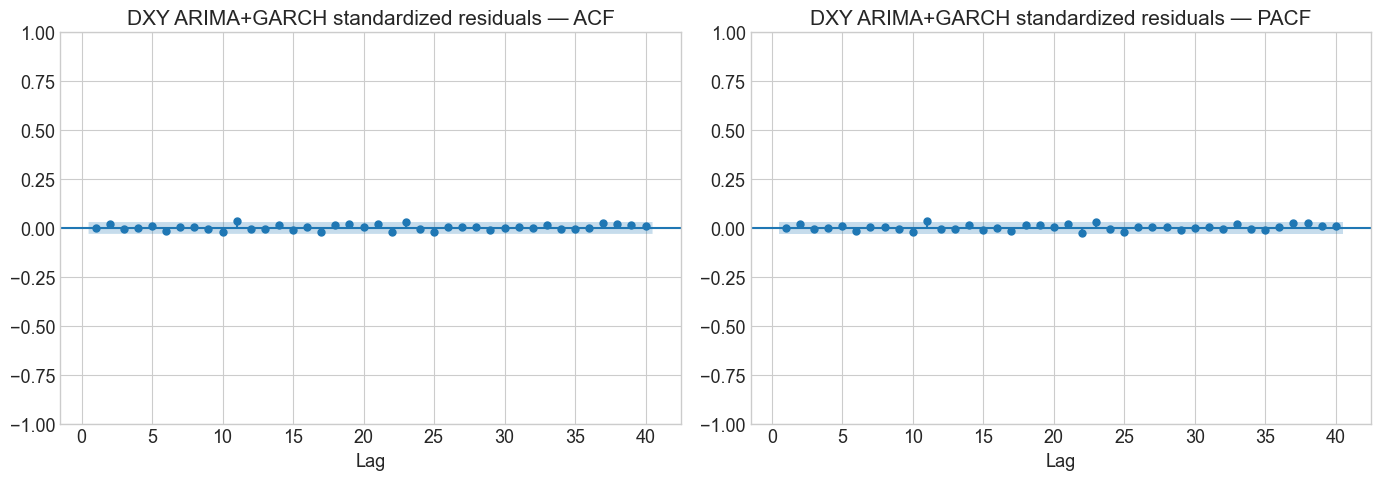

In [13]:


dxy_std_resid = pd.Series(twostep_fits[("DXY", "ARIMA+GARCH")]["garch"].std_resid).dropna()



fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(dxy_std_resid, lags=40, ax=axes[0], zero=False)

axes[0].set_title("DXY ARIMA+GARCH standardized residuals — ACF")

plot_pacf(dxy_std_resid, lags=40, ax=axes[1], zero=False, method="ywm")

axes[1].set_title("DXY ARIMA+GARCH standardized residuals — PACF")

for ax in axes:

    ax.set_xlabel("Lag")

plt.tight_layout()

fig_path = OUT_FIGS / "appendix_h_dxy_garch_standardized_residual_acf_pacf.pdf"

plt.savefig(fig_path, bbox_inches="tight")

print(f"Saved: {fig_path}")

plt.show()



### Rolling one-step OOS forecasts (loads saved CSVs from each part)


Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\figures\appendix_i_dxy_rolling_oos_forecasts.pdf
Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\figures\appendix_i_eem_rolling_oos_forecasts.pdf


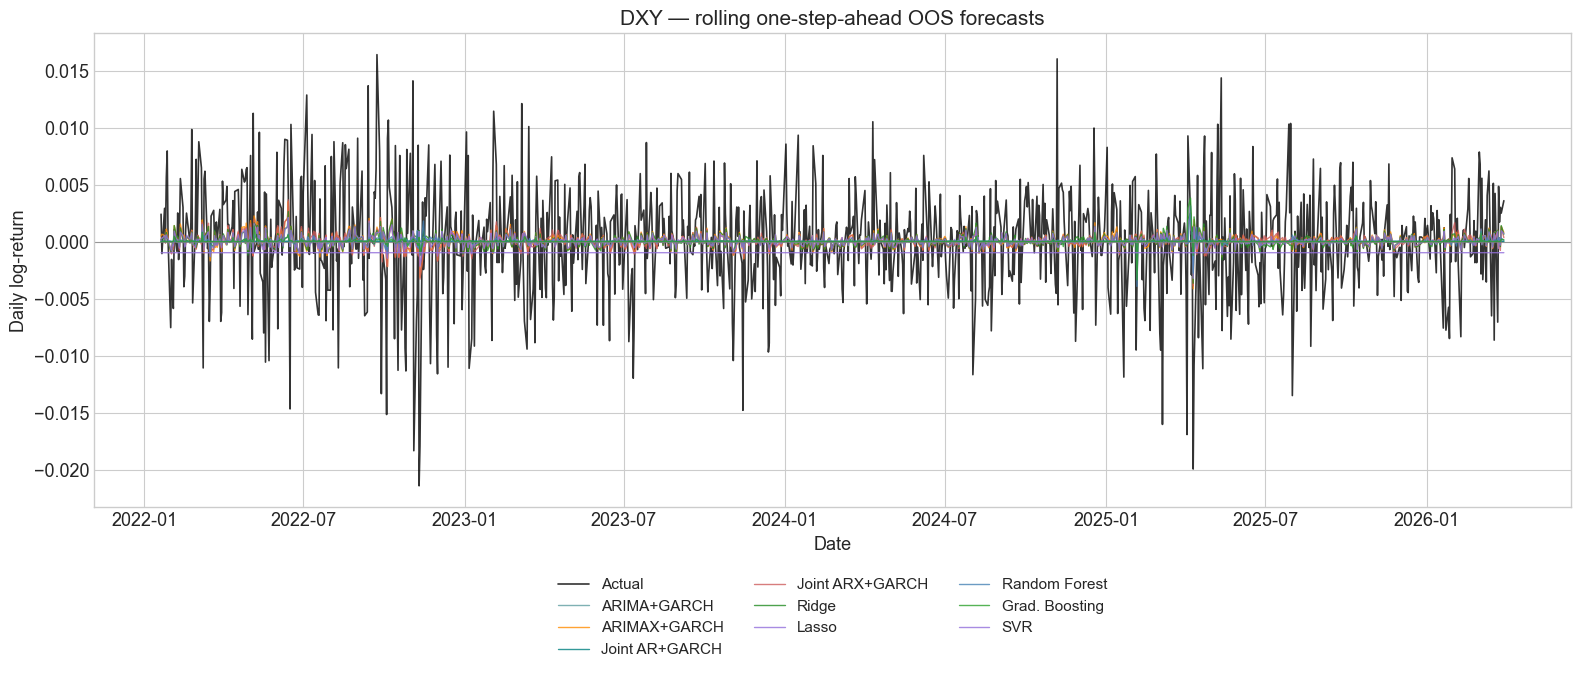

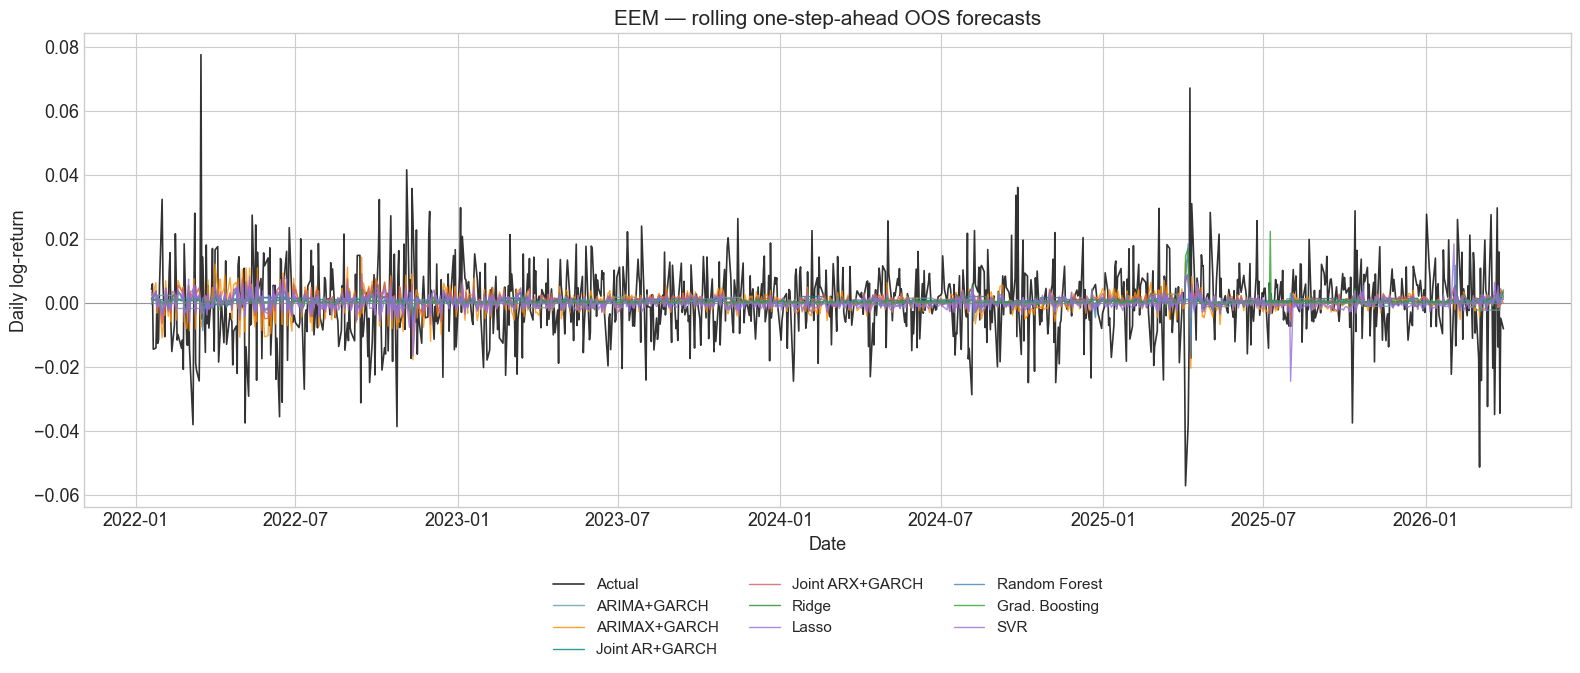

In [14]:


PREDICTION_ROWS = [

    ("ARIMA+GARCH", "arima_garch_predictions.csv", "cadetblue"),

    ("ARIMAX+GARCH", "arimax_garch_predictions.csv", "darkorange"),

    ("Joint AR+GARCH", "joint_ar_predictions.csv", "teal"),

    ("Joint ARX+GARCH", "joint_arx_predictions.csv", "indianred"),

    ("Ridge", "ridge_predictions.csv", "forestgreen"),

    ("Lasso", "lasso_predictions.csv", "mediumpurple"),

    ("Random Forest", "rf_predictions.csv", "steelblue"),

    ("Grad. Boosting", "gb_predictions.csv", "tab:green"),

    ("SVR", "svr_predictions.csv", "mediumpurple"),

]





def load_prediction_csv(panel, filename):

    path = panel["spec"]["root"] / "data" / "processed" / filename

    if not path.exists():

        return None

    return pd.read_csv(path, index_col=0, parse_dates=True)





def plot_separate_oos_forecasts(asset, panel):

    forecasts = {}

    actual = None

    for label, filename, color in PREDICTION_ROWS:

        df = load_prediction_csv(panel, filename)

        if df is None:

            continue

        forecasts[label] = (df["predicted"], color)

        if actual is None:

            actual = df["actual"]



    if actual is None:

        raise FileNotFoundError(f"No prediction CSVs found for {asset}")



    fig, ax = plt.subplots(figsize=(16, 7))

    ax.plot(actual.index, actual, color="black", lw=1.2, label="Actual", alpha=0.8)

    for label, (pred, color) in forecasts.items():

        ax.plot(pred.index, pred, lw=1.0, label=label, color=color, alpha=0.8)

    ax.axhline(0, color="grey", lw=0.8, alpha=0.7)

    ax.set_title(f"{asset} — rolling one-step-ahead OOS forecasts")

    ax.set_ylabel("Daily log-return")

    ax.set_xlabel("Date")

    ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)

    plt.tight_layout()

    path = OUT_FIGS / f"appendix_i_{asset.lower()}_rolling_oos_forecasts.pdf"

    plt.savefig(path, bbox_inches="tight")

    print(f"Saved: {path}")

    return fig





for asset, panel in panels.items():

    plot_separate_oos_forecasts(asset, panel)

plt.show()



### Ridge / Lasso standardized coefficients


In [15]:


def fit_ridge_lasso_coefficients(panel):

    X_train = panel["X_train"]

    y_train = panel["y_train"]

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X_train)

    tscv = TimeSeriesSplit(n_splits=5)



    ridge_alphas = np.logspace(np.log10(0.001), np.log10(100_000.0), 100)

    lasso_alphas = np.logspace(np.log10(0.001), np.log10(100.0), 100)



    y_scaler = None

    y_fit = y_train

    target_scaled = False

    if panel["asset"] == "DXY":

        y_scaler = StandardScaler()

        y_fit = y_scaler.fit_transform(np.asarray(y_train).reshape(-1, 1)).ravel()

        target_scaled = True



    ridge = RidgeCV(alphas=ridge_alphas, cv=tscv)

    lasso = LassoCV(alphas=lasso_alphas, cv=tscv, max_iter=10000)

    ridge.fit(X_scaled, y_fit)

    lasso.fit(X_scaled, y_fit)



    coef_table = pd.DataFrame({

        "asset": panel["asset"],

        "feature": X_train.columns,

        "ridge_coefficient": ridge.coef_,

        "ridge_abs_coefficient": np.abs(ridge.coef_),

        "lasso_coefficient": lasso.coef_,

        "lasso_abs_coefficient": np.abs(lasso.coef_),

        "lasso_nonzero": lasso.coef_ != 0,

    })

    coef_table["ridge_alpha"] = float(ridge.alpha_)

    coef_table["lasso_alpha"] = float(lasso.alpha_)

    coef_table["target_scaled"] = target_scaled

    coef_table["coefficient_units"] = "standardized_y" if target_scaled else "raw_y"

    return coef_table





ridge_lasso_coefficients = pd.concat(

    [fit_ridge_lasso_coefficients(panel) for panel in panels.values()],

    ignore_index=True,

)

save_table(ridge_lasso_coefficients, "appendix_j_ridge_lasso_standardized_coefficients.csv")

ridge_lasso_coefficients.sort_values(["asset", "ridge_abs_coefficient"], ascending=[True, False]).head(20)



Saved: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\reports\tables\appendix_j_ridge_lasso_standardized_coefficients.csv


,asset,feature,ridge_coefficient,ridge_abs_coefficient,lasso_coefficient,lasso_abs_coefficient,lasso_nonzero,ridge_alpha,lasso_alpha,target_scaled,coefficient_units
12,DXY,^GSPC,-0.074316,0.074316,-0.070542,0.070542,True,657.933225,0.023101,True,standardized_y
4,DXY,EEM,-0.060181,0.060181,-0.040050,0.040050,True,657.933225,0.023101,True,standardized_y
13,DXY,vol_21,0.056783,0.056783,0.000000,0.000000,False,657.933225,0.023101,True,standardized_y
14,DXY,vol_63,-0.047622,0.047622,-0.000000,0.000000,False,657.933225,0.023101,True,standardized_y
6,DXY,^TNX,0.047485,0.047485,0.024877,0.024877,True,657.933225,0.023101,True,standardized_y
10,DXY,GBPUSD=X,-0.035855,0.035855,-0.019502,0.019502,True,657.933225,0.023101,True,standardized_y
0,DXY,target_lag1,-0.031610,0.031610,-0.000000,0.000000,False,657.933225,0.023101,True,standardized_y
2,DXY,target_lag3,-0.018147,0.018147,-0.000000,0.000000,False,657.933225,0.023101,True,standardized_y
5,DXY,HG=F,0.017258,0.017258,0.000000,0.000000,False,657.933225,0.023101,True,standardized_y
9,DXY,EURUSD=X,-0.016206,0.016206,-0.000000,0.000000,False,657.933225,0.023101,True,standardized_y


### Sanity checks


In [16]:


expected_files = [

    OUT_TABLES / "appendix_b1_twostep_garch_parameter_estimates_long.csv",

    OUT_TABLES / "appendix_b2_joint_ar_garch_parameter_estimates_long.csv",

    OUT_TABLES / "appendix_b3_joint_arx_garch_volatility_estimates_long.csv",

    OUT_TABLES / "appendix_b4_joint_arx_garch_aic_ranking_top3.csv",

    OUT_TABLES / "appendix_c1_arimax_coefficient_estimates.csv",

    OUT_TABLES / "appendix_c2_joint_arx_garch_coefficient_estimates.csv",

    OUT_TABLES / "appendix_d1_adf_kpss_exogenous_returns_by_panel.csv",

    OUT_TABLES / "appendix_d1_adf_kpss_exogenous_thesis_summary.csv",

    OUT_TABLES / "appendix_d2_exogenous_descriptive_statistics_by_panel.csv",

    OUT_TABLES / "appendix_d2_exogenous_descriptive_thesis_summary.csv",

    OUT_TABLES / "appendix_e_stepwise_arima_arimax_selection.csv",

    OUT_TABLES / "appendix_e2_garch_aic_tables.csv",

    OUT_TABLES / "appendix_j_ridge_lasso_standardized_coefficients.csv",

    OUT_FIGS / "appendix_h_dxy_garch_standardized_residual_acf_pacf.pdf",

    OUT_FIGS / "appendix_i_dxy_rolling_oos_forecasts.pdf",

    OUT_FIGS / "appendix_i_eem_rolling_oos_forecasts.pdf",

]



sample_check = pd.DataFrame([

    {"asset": asset, "modelling_rows": len(panel["y"]), "train_size": panel["train_size"], "test_size": len(panel["y"]) - panel["train_size"]}

    for asset, panel in panels.items()

])



file_check = pd.DataFrame({

    "path": [str(p.relative_to(ROOT)) for p in expected_files],

    "exists": [p.exists() for p in expected_files],

})



print("Sample sizes:")

print(sample_check.to_string())

print("\nOutput files:")

print(file_check.to_string())

assert file_check["exists"].all(), "Some appendix outputs are missing. Re-run the notebook from the top."

print("All appendix outputs were generated successfully.")



Sample sizes:
  asset  modelling_rows  train_size  test_size
0   DXY            5263        4210       1053
1   EEM            5258        4206       1052

Output files:
                                                                        path  exists
0      reports\tables\appendix_b1_twostep_garch_parameter_estimates_long.csv    True
1     reports\tables\appendix_b2_joint_ar_garch_parameter_estimates_long.csv    True
2   reports\tables\appendix_b3_joint_arx_garch_volatility_estimates_long.csv    True
3            reports\tables\appendix_b4_joint_arx_garch_aic_ranking_top3.csv    True
4                reports\tables\appendix_c1_arimax_coefficient_estimates.csv    True
5       reports\tables\appendix_c2_joint_arx_garch_coefficient_estimates.csv    True
6         reports\tables\appendix_d1_adf_kpss_exogenous_returns_by_panel.csv    True
7           reports\tables\appendix_d1_adf_kpss_exogenous_thesis_summary.csv    True
8   reports\tables\appendix_d2_exogenous_descriptive_statistics_b